In [18]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [19]:
df=pd.read_csv('multiple_linear_regression_dataset.csv')

In [20]:
df.head(20)

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         20 non-null     int64
 1   experience  20 non-null     int64
 2   income      20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


<Axes: xlabel='income', ylabel='Count'>

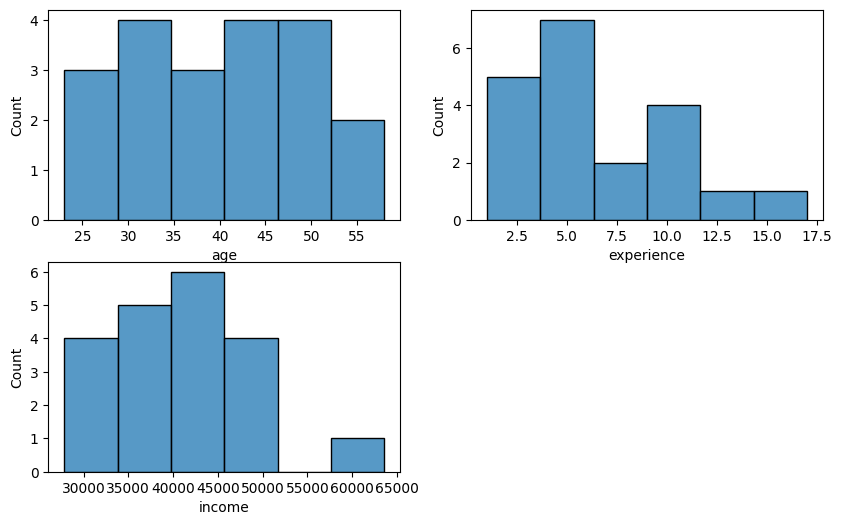

In [22]:
import seaborn as sns
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.histplot(df['age'])
plt.subplot(2,2,2)
sns.histplot(df['experience'])

plt.subplot(2,2,3)
sns.histplot(df['income'])

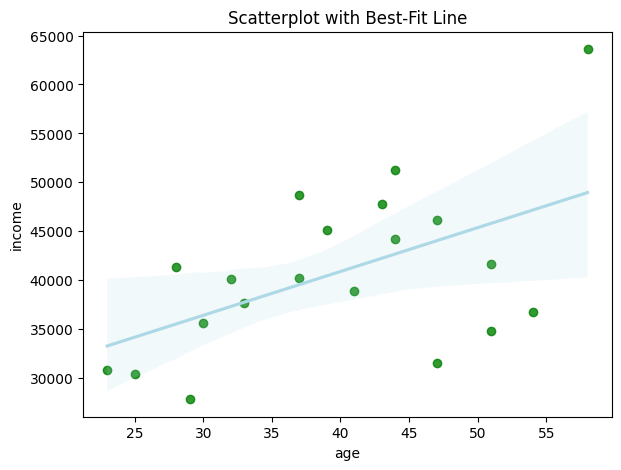

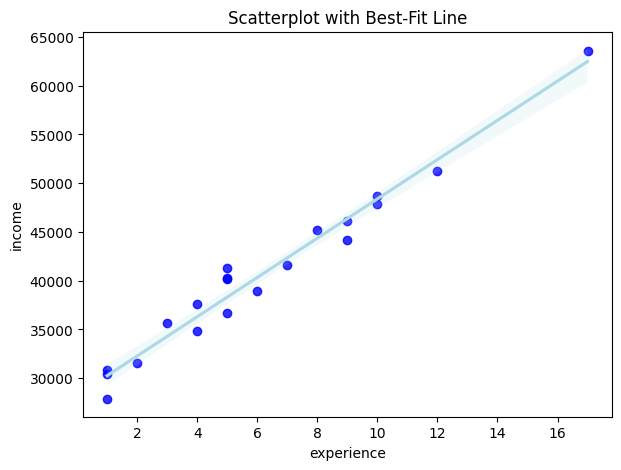

In [23]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
sns.regplot(data=df, x="age", y="income",color="green", line_kws={"color": "lightblue"})
plt.title("Scatterplot with Best-Fit Line")
plt.show()

plt.figure(figsize = (15,5))
plt.subplot(1,2,2)
sns.regplot(data=df, x="experience", y="income",color="blue", line_kws={"color": "lightblue"})
plt.title("Scatterplot with Best-Fit Line")
plt.show()

<Axes: >

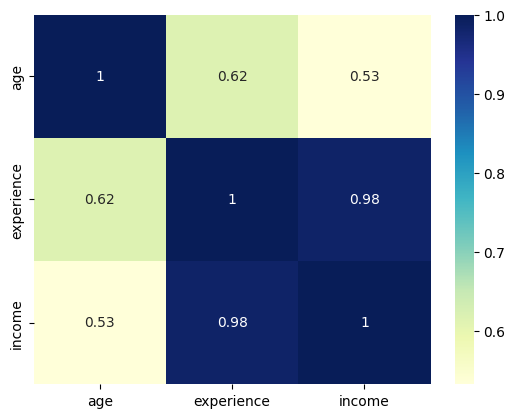

In [24]:
cor=df.corr()
sns.heatmap(cor, annot=True, cmap="YlGnBu")

In [25]:
x=df.drop(columns='income').values
y=df['income'].values


In [26]:
print(x)

[[25  1]
 [30  3]
 [47  2]
 [32  5]
 [43 10]
 [51  7]
 [28  5]
 [33  4]
 [37  5]
 [39  8]
 [29  1]
 [47  9]
 [54  5]
 [51  4]
 [44 12]
 [41  6]
 [58 17]
 [23  1]
 [44  9]
 [37 10]]


In [27]:
ones=np.ones((x.shape[0],1))
# print(ones)
x=np.hstack((ones,x))
print(x)

[[ 1. 25.  1.]
 [ 1. 30.  3.]
 [ 1. 47.  2.]
 [ 1. 32.  5.]
 [ 1. 43. 10.]
 [ 1. 51.  7.]
 [ 1. 28.  5.]
 [ 1. 33.  4.]
 [ 1. 37.  5.]
 [ 1. 39.  8.]
 [ 1. 29.  1.]
 [ 1. 47.  9.]
 [ 1. 54.  5.]
 [ 1. 51.  4.]
 [ 1. 44. 12.]
 [ 1. 41.  6.]
 [ 1. 58. 17.]
 [ 1. 23.  1.]
 [ 1. 44.  9.]
 [ 1. 37. 10.]]


In [28]:
y=y.reshape(-1,1)
print(y)

[[30450]
 [35670]
 [31580]
 [40130]
 [47830]
 [41630]
 [41340]
 [37650]
 [40250]
 [45150]
 [27840]
 [46110]
 [36720]
 [34800]
 [51300]
 [38900]
 [63600]
 [30870]
 [44190]
 [48700]]


In [30]:
XT=x.T
XTX=XT.dot(x)
XTX_inv=np.linalg.inv(XTX)
XTy=XT.dot(y)
B=XTX_inv.dot(XTy)
print(B)

[[31261.6898541 ]
 [  -99.19535546]
 [ 2162.40419192]]


In [31]:
ypred=x.dot(B)
y_mean=np.mean(y)
ss_total=np.sum((y-y_mean)**2)
ss_residual=np.sum((y-ypred)**2)
r2=1-(ss_residual/ss_total)
print("R-squared:", r2)

R-squared: 0.9773361310180797


In [33]:
input_features = ['age','experience']
output_features = ['income']
X = df[input_features]
Y = df[output_features]

In [34]:
X = X.to_numpy()
Y = Y.to_numpy()
print(X)
print(Y)

[[25  1]
 [30  3]
 [47  2]
 [32  5]
 [43 10]
 [51  7]
 [28  5]
 [33  4]
 [37  5]
 [39  8]
 [29  1]
 [47  9]
 [54  5]
 [51  4]
 [44 12]
 [41  6]
 [58 17]
 [23  1]
 [44  9]
 [37 10]]
[[30450]
 [35670]
 [31580]
 [40130]
 [47830]
 [41630]
 [41340]
 [37650]
 [40250]
 [45150]
 [27840]
 [46110]
 [36720]
 [34800]
 [51300]
 [38900]
 [63600]
 [30870]
 [44190]
 [48700]]


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_Y = StandardScaler()
y_train = scaler_Y.fit_transform(y_train) 
y_test = scaler_Y.transform(y_test)

In [38]:
m, n = X_train.shape
w = np.random.randn(n, 1) * 0.01
b = 0

In [39]:
def compute_gradient(X,y,w,b):
    dj_dw  = np.zeros((n,1))
    dj_db = 0
    no_of_observations, no_of_features = X.shape
    for i in range(no_of_observations):
        # err = (np.dot(X[i],w)- y[i])
        err = (np.dot(X[i], w) + b - y[i])
        for j in range(no_of_features):
            dj_dw[j] = dj_dw[j] + err * X[i][j]
        dj_db = dj_db + err
    dj_dw = dj_dw / no_of_observations
    dj_db = dj_db / no_of_observations
    return dj_dw,dj_db

In [40]:
iterations = 5000  
learning_rate = 0.01 

for i in range(iterations):
    change_in_w, change_in_b = compute_gradient(X_train, y_train, w, b)
    w -= learning_rate * change_in_w
    b -= learning_rate * change_in_b
    if i % 500 == 0:
        loss = mean_squared_error(y_train, np.dot(X_train, w) + b)
        print(f"Iteration {i}, Loss: {loss}")

y_pred_scaled = np.dot(X_test, w) + b  
y_pred = scaler_Y.inverse_transform(y_pred_scaled)
y_test_original = scaler_Y.inverse_transform(y_test)

Iteration 0, Loss: 0.9550402545756691
Iteration 500, Loss: 0.02741062431722912
Iteration 1000, Loss: 0.025885787989356743
Iteration 1500, Loss: 0.025878645995202586
Iteration 2000, Loss: 0.025878612538549704
Iteration 2500, Loss: 0.025878612381822094
Iteration 3000, Loss: 0.025878612381087907
Iteration 3500, Loss: 0.02587861238108446
Iteration 4000, Loss: 0.025878612381084454
Iteration 4500, Loss: 0.025878612381084447


In [41]:
mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
print("Final MSE of our model:", mse)
print("Final R² Score of our model:", r2)

Final MSE of our model: 753796.7693730636
Final R² Score of our model: 0.9387098237078204


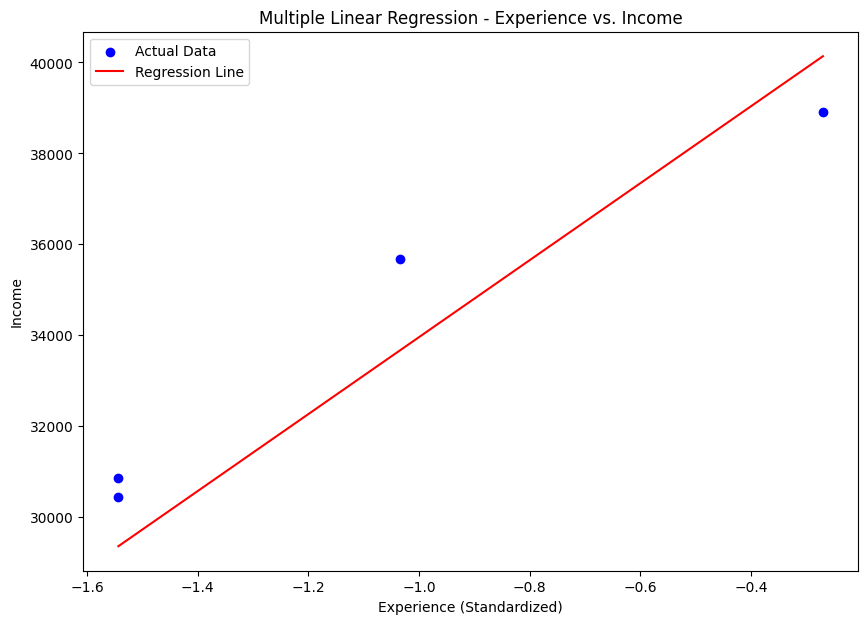

In [42]:
plt.figure(figsize=(10, 7))
plt.scatter(X_test[:, 1], y_test_original, color='blue', label='Actual Data')
x_line = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 100)
y_line = w[1] * x_line + b  
y_line = scaler_Y.inverse_transform(y_line.reshape(-1, 1)).flatten()  
plt.plot(x_line, y_line, color='red', label='Regression Line')

plt.xlabel("Experience (Standardized)")
plt.ylabel("Income")
plt.title("Multiple Linear Regression - Experience vs. Income")
plt.legend()
plt.show()

In [43]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_predefined = model.predict(X_test)
mse_predefined_method = mean_squared_error(y_test, y_pred_predefined)
r2_predefined_method = r2_score(y_test, y_pred_predefined)
print(f"MSE: {mse}")
print(f"R² Score: {r2}")

MSE: 753796.7693730636
R² Score: 0.9387098237078204
